# Progetto NLP

In [ ]:
!pip install huggingface_hub
!pip install hf_xet
!pip install -U transformers bitsandbytes
!pip install sentence-transformers
!pip install evaluate
!pip install trl
!pip install -U peft
!pip install -U nltk
!pip install bert_score
!pip install sacrebleu
!pip install mauve-text
!pip install git+https://github.com/google-research/bleurt.git

In [2]:
# Librerie
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import json
import nltk
import matplotlib.pyplot as plt
import evaluate
import zipfile

from IPython.display import display, Markdown
from tqdm.notebook import tqdm
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoModel,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    pipeline
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from collections import Counter
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import word_tokenize

from sentence_transformers import SentenceTransformer
from textblob import TextBlob

from huggingface_hub import notebook_login
from huggingface_hub.hf_api import HfFolder
HfFolder.save_token("TOKEN")

In [3]:
nltk.download('punkt', download_dir='/kaggle/working/nltk_data')
nltk.download('wordnet', download_dir='/kaggle/working/nltk_data')
nltk.download('omw-1.4', download_dir='/kaggle/working/nltk_data')

 
nltk.data.path.append('/kaggle/working/nltk_data')

zip_path = '/kaggle/working/nltk_data/corpora/wordnet.zip'
extract_path = '/kaggle/working/nltk_data/corpora/'
nltk.data.path.append('/kaggle/working/nltk_data')

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

[nltk_data] Downloading package punkt to /kaggle/working/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /kaggle/working/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## Dataset

In [ ]:
df = pd.read_csv('/kaggle/input/mental-disorders-with-classification/train_with_classification.csv')

## Modelli considerati

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
models = ['meta-llama/Llama-3.2-3B-Instruct',
          'Qwen/Qwen2.5-3B-Instruct',
          'google/gemma-3-4b-it']

def set_model(model_name):
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if model_name != 'google/gemma-3-4b-it':
        model = AutoModelForCausalLM.from_pretrained(model_name)
        model = model.to(device)
    
        
        if tokenizer.pad_token is None:
            print("Tokenizer has no pad token.")
            tokenizer.pad_token = tokenizer.eos_token
    else:
        torch_dtype = torch.bfloat16
        model = AutoModelForCausalLM.from_pretrained("google/gemma-3-4b-it",
                                                      device_map="auto",
                                                      torch_dtype=torch_dtype,
                                                      attn_implementation="eager")
    return tokenizer, model

### Modello META-LLAMA

In [ ]:
tokenizer_meta, model_meta = set_model(models[0])

### Modello QWEN

In [ ]:
tokenizer_qwen, model_qwen = set_model(models[1]) 

### Modello GEMMA3

In [ ]:
tokenizer_gemma3, model_gemma3 = set_model(models[2])
pipe = pipeline("text-generation", model=model_gemma3, tokenizer=tokenizer_gemma3)
stop_token_ids = [tokenizer_gemma3.eos_token_id, tokenizer_gemma3.convert_tokens_to_ids("<end_of_turn>")]

## Generazione delle risposte

In [ ]:
# Considero la prima occorenza di ogni domanda
unique_questions_df = df.drop_duplicates(subset='Context')
train_df, test_df = train_test_split(unique_questions_df, test_size=0.3, random_state=42)

In [ ]:
 
def get_chat(user,system=None,disorder=None):
    chat = []
    if system:
        if disorder:
            system = f"""Given the patient's situation and the identified mental health disorder ({disorder}), 
                        respond empathetically as a professional psychologist. 
                        Your response should acknowledge the patient's feelings and offer supportive and understanding
                        guidance, without directly naming the disorder. 
                        Focus on providing emotional support and suggesting practical steps for improvement.
                     """
        else:
            system = """Act like a professional psychologist. 
                        You must respond empathetically and professionally in one paragraph without items.
                     """
        chat.append({"role": "system", "content": system})
    chat.append({"role": "user", "content": user})
    return chat

In [ ]:
tqdm.pandas(desc="Generando risposte")

def generate_response(row, model, tokenizer, model_name, prompt='neutrale'):
    if prompt == 'neutrale':
        chat = get_chat(row['Context'])
    elif prompt == 'generico':
        chat = get_chat(row['Context'], system=True)
    elif prompt == 'specializzato':
        chat = get_chat(user=row['Context'], system=True, disorder=row['Disorders'])

    if model_name != 'gemma3':
        prompt = tokenizer.apply_chat_template(chat, tokenize=True, 
                                                       add_generation_prompt=True, 
                                                       return_tensors="pt").to(device)
        outputs = model.generate(prompt.to(device), 
                                 max_new_tokens=256, # Numero massimo di token generati
                                 pad_token_id=tokenizer.pad_token_id,
                                 temperature=0.85,   # Temperatura per la generazione
                                 top_k=64,       #Numero massimo di token considerati
                                 top_p=0.93      #Valore per il nucleus sampling
                                 repetition=1,   #Penalità per la ripetizione
                                 do_sample=True) # Abilita la generazione con sampling per usare temp/top_p/top_k
    
        answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
        answer = answer.split("assistant\n", 1)[1] if "assistant\n" in answer else answer
        
    else:
        prompt = pipe.tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
        output = pipe(prompt, max_new_tokens=256, 
                      do_sample=True, temperature=0.85, 
                      top_k=64, top_p=0.93, 
                      eos_token_id=stop_token_ids, 
                      disable_compile=True)
        answer =  output[0]['generated_text'].split('model\n')[1]
        
    return answer

def apply_with_progress(df, model, tokenizer, prompt, desc_msg, filename, model_name):
    print(desc_msg)
    df[f'{model_name} {prompt}'] = df.progress_apply(generate_response_row, axis=1, 
                                                     args=(model, tokenizer, model_name, prompt))
    df.to_csv(f'/kaggle/working/{filename}', index=False)
    print(f"Salvataggio completato: /kaggle/working/{filename}")
    return df

### Qwen

In [ ]:
# Prompt neutrale
test_df = apply_with_progress(test_df, model_qwen, 
                              tokenizer_qwen,'neutrale', 
                              "⚙️ Generando risposte per prompt neutrale...", 
                              'responses_neutrale.csv','qwen')
# Prompt generico
test_df = apply_with_progress(test_df, model_qwen, 
                              tokenizer_qwen, 'generico', 
                              "⚙️ Generando risposte per prompt generico...", 
                              'responses_generico.csv','qwen')
# Prompt specializzato
test_df = apply_with_progress(test_df, model_qwen, 
                              tokenizer_qwen, 'specializzato', 
                              "⚙️ Generando risposte per prompt specializzato...", 
                              'responses_specializzato.csv','qwen')

### Meta/LLama

In [ ]:
# Prompt neutrale
test_df = apply_with_progress(test_df, model_meta, 
                              tokenizer_meta,'neutrale', 
                              "⚙️ Generando risposte per prompt neutrale...", 
                              'responses_neutrale.csv','meta')
# Prompt generico
test_df = apply_with_progress(test_df, model_meta, 
                              tokenizer_meta, 'generico', 
                              "⚙️ Generando risposte per prompt generico...", 
                              'responses_generico.csv','meta')
# Prompt specializzato
test_df = apply_with_progress(test_df, model_meta, 
                              tokenizer_meta, 'specializzato', 
                              "⚙️ Generando risposte per prompt specializzato...", 
                              'responses_specializzato.csv','meta')

### Gemma 3

In [ ]:
# Prompt neutrale
test_df = apply_with_progress(test_df, model_gemma3, 
                              tokenizer_gemma3, 'neutrale', 
                              "⚙️ Generando risposte per prompt neutrale...", 
                              'responses_neutrale.csv','gemma3')
# Prompt generico
test_df = apply_with_progress(test_df, model_gemma3, 
                              tokenizer_gemma3, 'generico', 
                              "⚙️ Generando risposte per prompt generico...", 
                              'responses_generico.csv','gemma3')
# Prompt specializzato
test_df = apply_with_progress(test_df, model_gemma3,
                              tokenizer_gemma3, 'specializzato',
                              "⚙️ Generando risposte per prompt specializzato...",
                              'responses_specializzato.csv','gemma3')

# Metriche di valutazione

In [4]:
df_test = pd.read_csv('/kaggle/input/mental-disorders-with-classification/test_responses_qwen_meta_gemma3.csv')
df_test = df_test.map(lambda x: x.replace('\n', '') if isinstance(x, str) else x)

In [5]:
df_test

,Context,Response,Disorders,qwen neutrale,qwen generico,qwen specializzato,meta neutrale,meta generico,meta specializzato,gemma3 neutrale,gemma3 generico,gemma3 specializzato
0,"I told her that if daddy dies, we will never s...",Children often have a difficult time expressin...,"Acute Stress Disorder, Adjustment Disorder wit...",I'm sorry to hear that you've shared such a di...,It sounds like your child is grappling with co...,I'm really sorry to hear that you and your dau...,I can imagine how distressing and overwhelming...,It sounds like a very distressing and intense ...,(I'm speaking in a gentle and empathetic tone)...,This is a profoundly disturbing and heartbreak...,It sounds like you’re experiencing a profoundl...,"Okay, that sounds incredibly difficult and hea..."
1,"My best friend and I were pranking her friend,...",In order for your friend to forgive you she'd ...,"Adjustment Disorders, Anxiety Disorder due to ...",I'm really sorry to hear about the situation y...,I understand how you must be feeling overwhelm...,I'm really sorry to hear about what happened. ...,I can sense the weight of guilt and regret in ...,I can sense the weight of your guilt and distr...,I can sense the overwhelming emotions you're f...,"Okay, wow. This is a really tough situation, a...",It sounds like you're experiencing a profound ...,"Okay, thank you for sharing this with me. It t..."
2,How do therapists classify the type of persona...,"This is a great question, and I am happy to ha...","Acute Stress Disorder, Adjustment Disorder wit...","As a therapist, classifying a client's persona...",Therapists do not typically classify clients i...,Therapists don't typically classify a client's...,"In the field of psychology, therapists often u...","As a therapist, I categorize personality types...","As a therapist, I'd like to clarify that the c...",You’ve hit on a really interesting and nuanced...,It’s understandable to be curious about how th...,"Okay, let's talk about how therapists approach..."
3,I don't remember when the voices in my head st...,This isn't something you can do on your own. I...,"Hallucinogen Use Disorder, Schizophrenia, Toxi...",I'm sorry to hear about the challenges you're ...,I understand how challenging it must be to dea...,I understand how you feel. The voices in your ...,I'm so sorry to hear that you're experiencing ...,I can sense the distress and frustration you'r...,I'm so sorry to hear that you're experiencing ...,"Okay, it takes a lot of courage to even talk a...",It sounds incredibly distressing to be experie...,"Okay, thank you for sharing this with me. It t..."
4,I have twin toddlers. I experienced a death of...,"First, let me say that you are a survivor and ...","Acute Stress Disorder, Anxiety Disorder due to...",I'm really sorry to hear about the challenges ...,I understand that you are facing a complex arr...,I can really understand how overwhelming and d...,I can sense the depth of your emotional pain a...,It sounds like you've experienced a deeply pai...,It takes immense courage to share your story w...,"Okay, wow. That’s a *lot* to carry. It’s incre...",It sounds like you’re carrying an immense and ...,"Okay, thank you for sharing all of that with m..."
...,...,...,...,...,...,...,...,...,...,...,...,...
312,"I'm planning to have baby, so I have to quit s...",Hi. Good for you in planning ahead to do what'...,"Nicotine Use Disorder, Anxiety Disorder due to...","I'm sorry to hear about your situation, but it...","Given your situation, it's understandable that...",I understand how challenging this time is for ...,Congratulations on your pregnancy and decision...,Congratulations on your decision to quit smoki...,Congratulations on your decision to start a fa...,"Okay, congratulations on planning a baby – tha...",It sounds incredibly challenging and brave of ...,"Okay, thank you for sharing this with me. It t..."
313,"He isn't violent, but he has anger issues and ...","From what you write, you're not too happy with..

In [42]:
df_test.iloc[3]

Context                 I don't remember when the voices in my head st...
Response                This isn't something you can do on your own. I...
Disorders               Hallucinogen Use Disorder, Schizophrenia, Toxi...
qwen neutrale           I'm sorry to hear about the challenges you're ...
qwen generico           I understand how challenging it must be to dea...
qwen specializzato      I understand how you feel. The voices in your ...
meta neutrale           I'm so sorry to hear that you're experiencing ...
meta generico           I can sense the distress and frustration you'r...
meta specializzato      I'm so sorry to hear that you're experiencing ...
gemma3 neutrale         Okay, it takes a lot of courage to even talk a...
gemma3 generico         It sounds incredibly distressing to be experie...
gemma3 specializzato    Okay, thank you for sharing this with me. It t...
Name: 3, dtype: object

In [10]:
bertscore = evaluate.load("bertscore")
bleurt = evaluate.load("bleurt")

def get_similarity(reference,generated):
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform([generated, reference])
    return cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]
    
def get_bertscore(reference, generated):
    score = bertscore.compute(predictions=[generated], references=[reference], lang="en")
    return score['f1'][0]

def get_bleurt(reference, generated):
    score = bleurt.compute(predictions=[generated], references=[reference])
    return score['scores'][0]
    
def get_meteor(reference, generated):
    return meteor_score([word_tokenize(reference)], word_tokenize(generated))

In [11]:
def evaluate_metrics(row,model_name):
    prompts = ['neutrale','generico','specializzato']
    result = {}
    
    reference = row['Response']
    for prompt in prompts:
        generated = row[f'{model_name} {prompt}']

        # Similarity
        sim = get_similarity(reference,generated)
        result[f'similarity {prompt}'] = sim

        # Bertscore
        bertscore = get_bertscore(reference,generated)
        result[f'bertscore {prompt}'] = bertscore

        # Bleurt
        bleurt = get_bleurt(reference,generated)
        result[f'bleurt {prompt}'] = bleurt 

        # Meteor
        meteor = get_meteor(reference,generated)
        result[f'meteor {prompt}'] = meteor 

    return result


In [ ]:
def plot_metriche(df_metriche,model_name):
    metriche = ['similarity', 'bertscore', 'bleurt', 'meteor']
    prompt = ['neutrale', 'generico', 'specializzato']
    
    data = {'metrica': [], 'prompt': [], 'valore': []}
    
    for m in metriche:
        for p in prompt:
            col_name = f"{m} {p}"
            data['metrica'].append(m)
            data['prompt'].append(p)
            data['valore'].append(df_metriche[col_name].mean())
    
    df_plot = pd.DataFrame(data)
    
    
    sns.set(style="whitegrid", font_scale=1.2)
    plt.figure(figsize=(10, 6))
    
    ax = sns.barplot(
        data=df_plot,
        x='metrica',
        y='valore',
        hue='prompt',
        palette='viridis'
    )
    
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3,fontsize=8)
    
    plt.title(f"Confronto delle metriche per tipo di prompt - {model_name}", fontsize=16)
    plt.xlabel("Metrica")
    plt.ylabel("Valore medio")
    plt.legend(title="Prompt")
    plt.tight_layout()
    plt.savefig(f"metriche.jpg", format='jpg', quality=95)
    plt.show()

### Qwen

In [ ]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_qwen = df_test.progress_apply(lambda row: evaluate_metrics(row, 'qwen'), 
                                          axis=1, result_type='expand')
df_metriche_qwen.to_csv("metriche_qwen.csv", index=False)

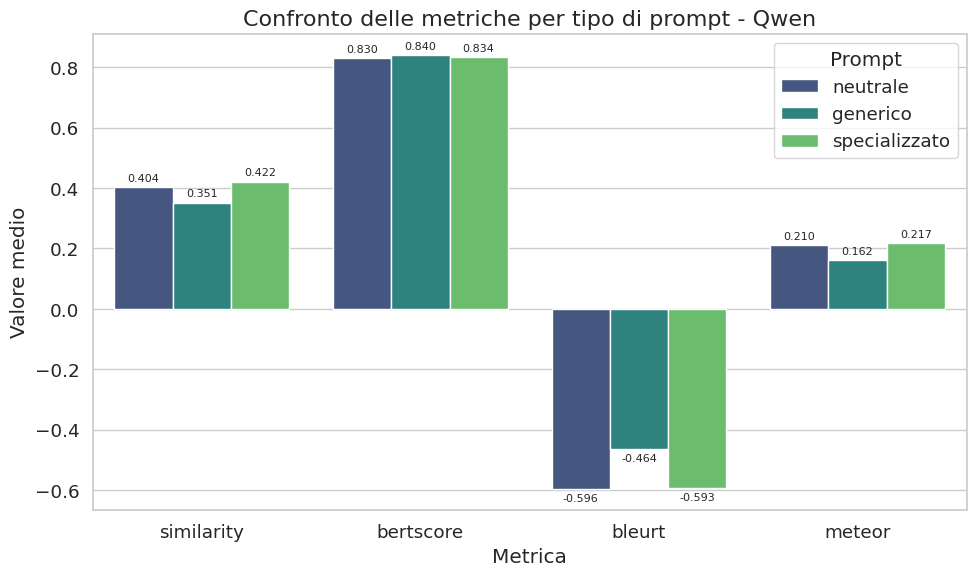

In [26]:
df_metriche_qwen = pd.read_csv('/kaggle/working/metriche_qwen.csv')
plot_metriche(df_metriche_qwen,'Qwen')

### Meta/LLama

In [13]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_meta = df_test.progress_apply(lambda row: evaluate_metrics(row, 'meta'), 
                                          axis=1, result_type='expand')
df_metriche_meta.to_csv("metriche_meta.csv", index=False)

Calcolo delle metriche...:   0%|          | 0/317 [00:00<?, ?it/s]

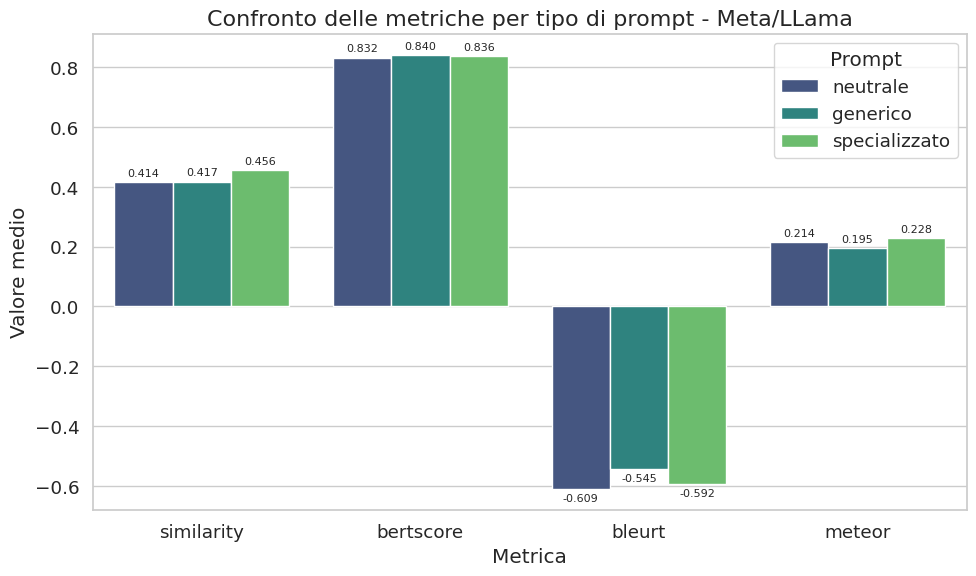

In [27]:
df_metriche_meta = pd.read_csv('/kaggle/working/metriche_meta.csv')
plot_metriche(df_metriche_meta,'Meta LLama')

### Gemma3

In [14]:
tqdm.pandas(desc="Calcolo delle metriche...")
df_metriche_gemma3 = df_test.progress_apply(lambda row: evaluate_metrics(row, 'gemma3'), 
                                          axis=1, result_type='expand')
df_metriche_gemma3.to_csv("metriche_gemma3.csv", index=False)

Calcolo delle metriche...:   0%|          | 0/317 [00:00<?, ?it/s]

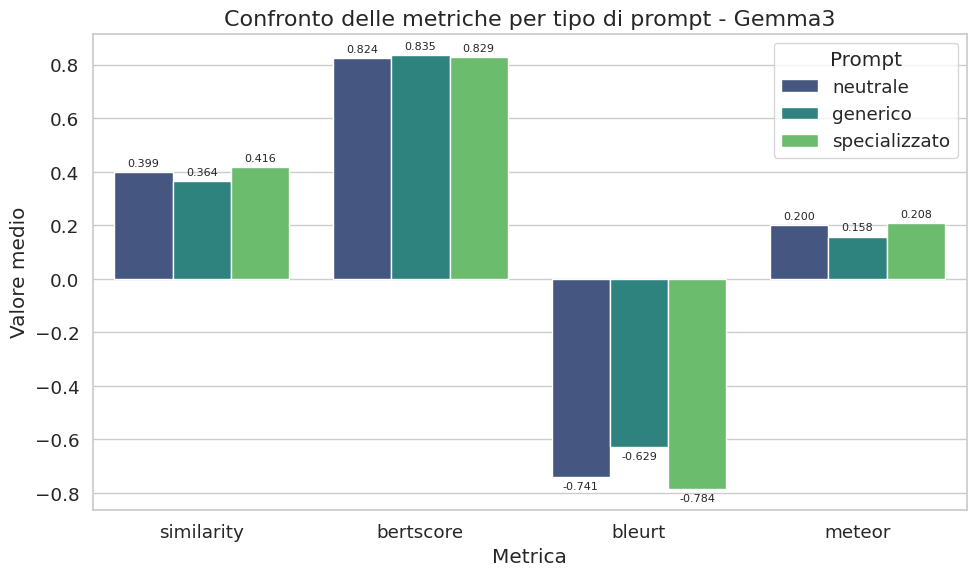

In [28]:
df_metriche_gemma3 = pd.read_csv('/kaggle/working/metriche_gemma3.csv')
plot_metriche(df_metriche_gemma3,'Gemma3')